In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("annthyroid_21feat_normalised.csv")
data.head()
x = data.drop('class', axis=1)
y = data['class']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

imp = SimpleImputer(missing_values=np.nan, strategy='mean')
x_train_imputed = imp.fit_transform(x_train)
x_test_imputed = imp.fit_transform(x_test)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_imputed)
x_test_scaled = scaler.fit_transform(x_test_imputed)

Accuracy:  0.9652777777777778
Precision:  0.8983050847457628
Recall:  0.5463917525773195
R2_score:  0.4473060005680467


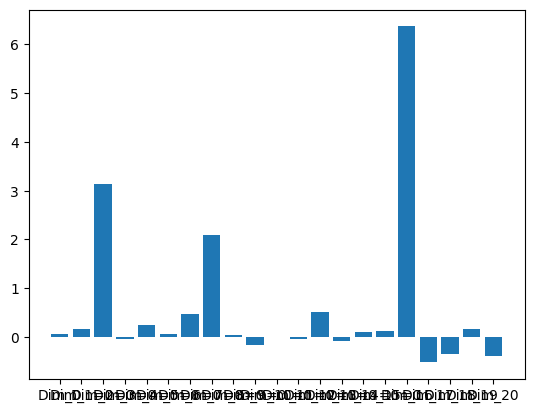

In [3]:
logreg = LogisticRegression()
logreg.fit(x_train_scaled, y_train)
y_pred = logreg.predict(x_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("R2_score: ",r2)
plt.bar(x_train.columns,logreg.coef_[0])
plt.show()

In [4]:
svm = SVC(kernel="linear")
svm.fit(x_train_scaled, y_train)
y_pred = svm.predict(x_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("R2_score: ",r2)

Accuracy:  0.9701388888888889
Precision:  0.9090909090909091
Recall:  0.6185567010309279
R2_score:  0.5246831604885202


Feature:  Dim_0  Importance:  0.0
Feature:  Dim_1=0  Importance:  0.0
Feature:  Dim_2=0  Importance:  0.1768620798182251
Feature:  Dim_3=0  Importance:  0.0
Feature:  Dim_4=0  Importance:  -0.011053879988639048
Feature:  Dim_5=0  Importance:  0.0
Feature:  Dim_6=0  Importance:  0.0
Feature:  Dim_7=0  Importance:  0.07737715992047345
Feature:  Dim_8=0  Importance:  0.0
Feature:  Dim_9=0  Importance:  0.011053879988639048
Feature:  Dim_10=0  Importance:  0.0
Feature:  Dim_11=0  Importance:  0.0
Feature:  Dim_12=0  Importance:  0.0
Feature:  Dim_13=0  Importance:  0.0
Feature:  Dim_14=0  Importance:  0.0
Feature:  Dim_15=0  Importance:  -0.011053879988639048
Feature:  Dim_16  Importance:  0.5969095193865096
Feature:  Dim_17  Importance:  0.033161639965917256
Feature:  Dim_18  Importance:  0.0
Feature:  Dim_19  Importance:  0.0
Feature:  Dim_20  Importance:  0.0


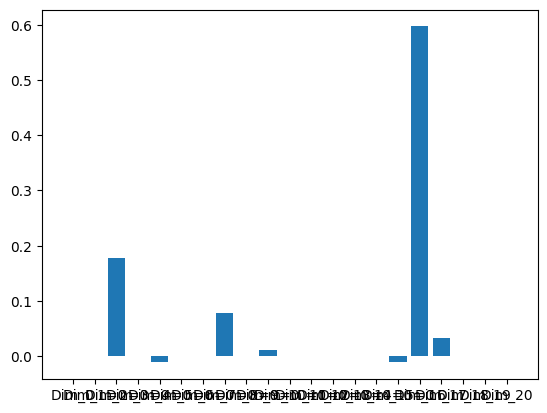

In [6]:
# LOFO
x_test_copy = x_test_scaled.copy()
x_train_copy = x_train_scaled.copy()
importances = []
for col in range(len(x_train.columns)):
  x_pruned = np.delete(x_train_scaled,col,1)
  svm = SVC(kernel="linear")
  svm.fit(x_pruned, y_train)
  x_test_pruned = np.delete(x_test_scaled,col,1)
  y_pred_pr = svm.predict(x_test_pruned)
  accuracy_pr = accuracy_score(y_test, y_pred_pr)
  r2_pr = r2_score(y_test, y_pred_pr)
  importance = r2 - r2_pr
  print("Feature: ", x_train.columns[col], " Importance: ", importance)
  importances.append(importance)

plt.bar(x_train.columns,importances)
plt.show()